In [37]:
!pip install yfinance

In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
%matplotlib inline

In [40]:
ticker = "^NSEI"
data = yf.download(ticker, start="2016-06-08", end="2026-06-08")
data_1 = yf.download( "^GSPC",start="2016-06-08", end="2026-06-08")
oil = yf.download("CL=F", start="2016-01-01", end="2026-06-01")
usd_inr = yf.download("INR=X", start="2016-01-01", end="2026-06-01")
gold= yf.download("GC=F",start="2016-01-01", end="2026-06-01" )
# Download India VIX
vix = yf.download("^INDIAVIX", start="2016-06-08", end="2026-06-08")
vix.columns = vix.columns.get_level_values(0)

# Download Bank Nifty
banknifty = yf.download("^NSEBANK", start="2016-06-08", end="2026-06-08")
banknifty.columns = banknifty.columns.get_level_values(0)
for df in [data, data_1, oil, usd_inr, gold]:
    df.columns = df.columns.get_level_values(0)


/tmp/ipykernel_866/3866755433.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2016-06-08", end="2026-06-08")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_866/3866755433.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_1 = yf.download( "^GSPC",start="2016-06-08", end="2026-06-08")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_866/3866755433.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil = yf.download("CL=F", start="2016-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_866/3866755433.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_inr = yf.download("INR=X", start="2016-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 comp

In [41]:
# Calculate the daily percentage change
data['Daily_Return'] = data['Close'].pct_change()
data['Oil_return'] = (oil['Close']
                        .reindex(data.index)
                        .ffill()
                        .pct_change()
                        .shift(1))

data['Gold']       = (gold['Close']
                        .reindex(data.index)
                        .ffill()
                        .pct_change()
                        .shift(1))

data['Us_stck']    = (data_1['Close']
                        .reindex(data.index)
                        .ffill()
                        .pct_change()
                        .shift(1))

data['Rupee_Ex']   = (usd_inr['Close']
                        .reindex(data.index)
                        .ffill()
                        .shift(1))

In [42]:
import numpy as np

# Calculate 20-day rolling volatility (annualized)
data['Rolling_Volatility'] = data['Daily_Return'].rolling(window=20).std() * np.sqrt(252)
data = data.dropna()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [44]:
data['Lagged_Return_1'] = data['Daily_Return'].shift(1)
data['Lagged_Return_2'] = data['Daily_Return'].shift(2)
data['Lagged_Vol'] = data['Rolling_Volatility'].shift(1)
data['Lagged_Vol_1'] = data['Volume'].rolling(window=5).mean().shift(1)
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['Trend_Ratio'] = (data['Close'] / data['SMA_50']).shift(1)
delta = data['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
data['RSI'] = (100 - (100 / (1 + gain/loss))).shift(1)

# FII flow data (most impactful — requires separate download)
# India VIX (fear index)
data['VIX'] = vix['Close'].reindex(data.index).ffill().shift(1)

# Put-Call ratio from NSE (measures market sentiment)
# Bank Nifty vs Nifty spread (sector rotation signal)
data['BankNifty_ratio'] = (banknifty['Close'] / data['Close']).shift(1)

# Distance from 20-day high
data['Dist_20high'] = (data['Close'] / data['Close'].rolling(20).max()).shift(1)

data['Vol_ratio'] = data['Volume'] / data['Volume'].rolling(20).mean()
data['Lagged_Vol_ratio'] = data['Vol_ratio'].shift(1)
data['Vol_zscore'] = (
    (data['Volume'] - data['Volume'].rolling(20).mean()) /
    data['Volume'].rolling(20).std()
).shift(1)
data['Target'] = np.where(data['Daily_Return'].shift(-1) > 0, 1, 0)

ml_data = data[['Lagged_Return_1','RSI', 'Lagged_Return_2','Dist_20high','BankNifty_ratio','VIX' ,'Lagged_Vol','Trend_Ratio','Lagged_Vol_1', 'Rupee_Ex','Gold','Oil_return','Us_stck','Lagged_Vol_ratio','Vol_zscore','Target']].dropna()

In [45]:
X = ml_data[['Lagged_Return_1', 'Lagged_Vol','Trend_Ratio','Gold','Us_stck','Oil_return','BankNifty_ratio','VIX' ]]
y = ml_data['Target']


In [46]:
split_index = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_daily_returns = data['Daily_Return'].loc[X_test.index]

In [47]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,        # reduced from 10
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    oob_score=True,
    random_state=42
)

In [48]:
model.fit(X_train, y_train)
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(importances)

Price
BankNifty_ratio    0.139683
Us_stck            0.131231
Lagged_Vol         0.130342
Trend_Ratio        0.128931
Lagged_Return_1    0.123258
VIX                0.119075
Oil_return         0.116659
Gold               0.110822
dtype: float64


In [49]:
ENTRY_COST = 120
SELL_TAX_PCT = 0.001
SELL_FLAT = 25

proba = model.predict_proba(X_test)[:, 1]
test_daily_returns = data['Daily_Return'].loc[X_test.index]

# Step 1 — find best threshold
results = []
for thresh in np.arange(0.30, 0.56, 0.01):
    signal = pd.Series(np.where(proba > thresh, 1, 0), index=X_test.index)
    changes = signal.diff()
    entries = (changes == 1)
    exits   = (changes == -1)

    if entries.sum() < 60:
        continue

    portfolio = 100000.0
    for date in X_test.index:
        if signal[date] == 1:
            portfolio *= (1 + test_daily_returns[date])
        if entries.get(date, False):
            portfolio -= ENTRY_COST
        if exits.get(date, False):
            portfolio -= (portfolio * SELL_TAX_PCT + SELL_FLAT)

    results.append({
        'threshold': round(thresh, 2),
        'net_after_costs': round(portfolio),
        'n_buys': int(entries.sum())
    })

results_df = pd.DataFrame(results)          # ✅ create first
best_threshold = results_df.loc[results_df['net_after_costs'].idxmax(), 'threshold']
print(results_df.to_string())
print(f"\nBest threshold: {best_threshold}")



   threshold  net_after_costs  n_buys
0       0.47            95383      61
1       0.48            93521      73
2       0.49            92169      83
3       0.50            89855      83
4       0.51           100973      85
5       0.52           100103      73
6       0.53           100812      63

Best threshold: 0.51


In [50]:
results_hold = []

for min_hold in [1, 2, 3, 5, 7, 10]:
    signal_raw = pd.Series(np.where(proba > best_threshold, 1, 0), index=X_test.index)
    signal = signal_raw.copy()

    holding_days = 0
    for i in range(1, len(signal)):
        if signal.iloc[i-1] == 1:
            holding_days += 1
            if holding_days < min_hold:
                signal.iloc[i] = 1
            else:
                holding_days = 0
        else:
            holding_days = 0

    changes = signal.diff()
    entries = (changes == 1)
    exits   = (changes == -1)

    portfolio = 100000.0
    portfolio_values = []
    for date in X_test.index:
        if signal[date] == 1:
            portfolio *= (1 + test_daily_returns[date])
        if entries.get(date, False):
            portfolio -= ENTRY_COST
        if exits.get(date, False):
            portfolio -= (portfolio * SELL_TAX_PCT + SELL_FLAT)
        portfolio_values.append(portfolio)

    final_val = round(portfolio)
    n_entries = int(entries.sum())
    results_hold.append({
        'min_hold_days': min_hold,
        'final_value': final_val,
        'n_trades': n_entries,
        'vs_buyhold': final_val - round(97684)
    })

hold_df = pd.DataFrame(results_hold)
print(hold_df.to_string())

# Step 3 — pick best holding period and build final portfolio
best_hold = hold_df.loc[hold_df['final_value'].idxmax(), 'min_hold_days']
print(f"\nBest holding period: {best_hold} days")

   min_hold_days  final_value  n_trades  vs_buyhold
0              1       100973        85        3289
1              2        95642        59       -2042
2              3       101508        47        3824
3              5        90649        36       -7035
4              7        96909        27        -775
5             10       101078        22        3394

Best holding period: 3 days


In [51]:
signal_raw = pd.Series(np.where(proba > best_threshold, 1, 0), index=X_test.index)
signal = signal_raw.copy()
holding_days = 0

for i in range(1, len(signal)):
    if signal.iloc[i-1] == 1:
        holding_days += 1
        if holding_days < best_hold:
            signal.iloc[i] = 1
        else:
            holding_days = 0
    else:
        holding_days = 0

changes = signal.diff()
entries = (changes == 1)
exits   = (changes == -1)

portfolio = 100000.0
portfolio_values = []
for date in X_test.index:
    if signal[date] == 1:
        portfolio *= (1 + test_daily_returns[date])
    if entries.get(date, False):
        portfolio -= ENTRY_COST
    if exits.get(date, False):
        portfolio -= (portfolio * SELL_TAX_PCT + SELL_FLAT)
    portfolio_values.append(portfolio)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [52]:
strategy_df = pd.DataFrame(index=X_test.index)   # ✅ initialize first
strategy_df['Strategy_Value_INR'] = portfolio_values
strategy_df['Market_Value_INR'] = 100000 * (1 + test_daily_returns).cumprod()

Buy & Hold:          ₹97,684.83
ML Model after costs: ₹101,507.94
N trades: 47


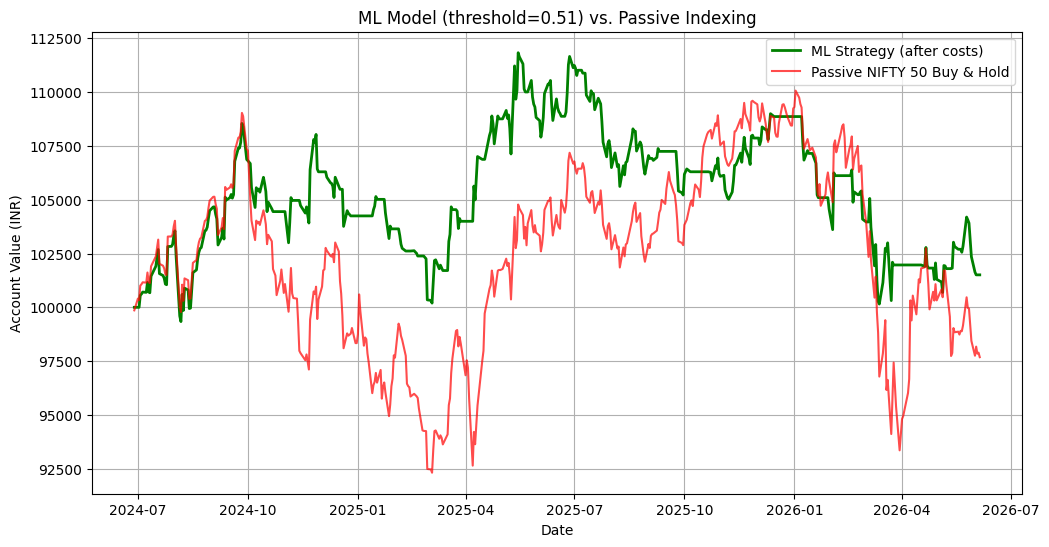

In [53]:
final_strat_val = strategy_df['Strategy_Value_INR'].iloc[-1]
final_market_val = strategy_df['Market_Value_INR'].iloc[-1]
print(f"Buy & Hold:          ₹{final_market_val:,.2f}")
print(f"ML Model after costs: ₹{final_strat_val:,.2f}")
print(f"N trades: {int(entries.sum())}")

plt.figure(figsize=(12, 6))
plt.plot(strategy_df.index, strategy_df['Strategy_Value_INR'],
         color='green', linewidth=2, label='ML Strategy (after costs)')
plt.plot(strategy_df.index, strategy_df['Market_Value_INR'],
         color='red', alpha=0.7, label='Passive NIFTY 50 Buy & Hold')
plt.title(f'ML Model (threshold={best_threshold}) vs. Passive Indexing')
plt.ylabel('Account Value (INR)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# Correct — use raw model predictions for evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Out-of-Sample Prediction Accuracy: {accuracy:.2%}")
print(classification_report(y_test, y_pred))

# Separate — trading signal for backtest only
# signal = np.where(proba > best_threshold, 1, 0)

Out-of-Sample Prediction Accuracy: 52.51%
              precision    recall  f1-score   support

           0       0.53      0.49      0.51       239
           1       0.52      0.56      0.54       239

    accuracy                           0.53       478
   macro avg       0.53      0.53      0.52       478
weighted avg       0.53      0.53      0.52       478

